In [1]:
# 1. Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 2. Loading the Dataset
df = pd.read_csv("Drug_Review_Dataset.csv")

In [3]:
# 3. Dataset Overview
df.head()

,drugName,condition,review,rating,usefulCount
0,Paracetamol,Arthritis,I had headaches & nausea while taking this for...,2,81
1,Metformin,Hypertension,<div>Side effects were bad when I used this fo...,1,23
2,Sertraline,Back Pain,"good results for Back Pain, will continue using.",9,39
3,Fluoxetine,Arthritis,<div>Side effects were bad when I used this fo...,6,57
4,Fluoxetine,Back Pain,Doctor prescribed this for Back Pain and it ac...,7,43


In [4]:
# 4. Checking Dataset Shape
df.shape

(5000, 5)

In [5]:
# 5. Viewing Column Names
df.columns

Index(['drugName', 'condition', 'review', 'rating', 'usefulCount'], dtype='object')

In [6]:
# 6. Inspecting Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   drugName     5000 non-null   object
 1   condition    4745 non-null   object
 2   review       4754 non-null   object
 3   rating       5000 non-null   int64 
 4   usefulCount  5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [7]:
# 7. Statistical Summary of Data
df.describe()

,rating,usefulCount
count,5000.000000,5000.000000
mean,6.046400,50.597800
std,2.906671,29.175515
min,1.000000,0.000000
25%,4.000000,25.000000
50%,7.000000,51.000000
75%,9.000000,76.000000
max,10.000000,100.000000


In [8]:
# 8. Missing Value Analysis
df.isnull().sum()

drugName         0
condition      255
review         246
rating           0
usefulCount      0
dtype: int64

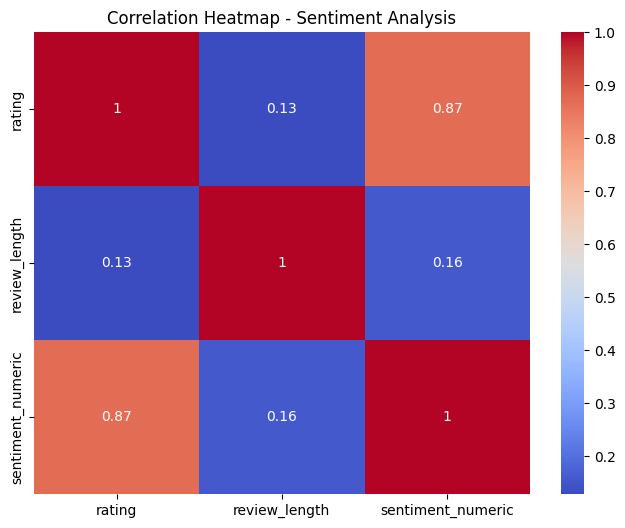

In [45]:
df['review_length'] = df['review'].astype(str).apply(len)

df['sentiment_numeric'] = df['sentiment'].map({'positive':1, 'negative':0})

plt.figure(figsize=(8,6))

corr = df[['rating','review_length','sentiment_numeric']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap - Sentiment Analysis")

plt.show()

In [46]:
# 10. Handling Missing Values
df = df.dropna(subset=['review','condition'])

In [47]:
# 11. Removing Duplicate Records
df = df.drop_duplicates()

In [48]:
# 12. Creating Sentiment Labels from Ratings
def sentiment_label(rating):
    if rating >= 7:
        return "positive"
    else:
        return "negative"

df["sentiment"] = df["rating"].apply(sentiment_label)

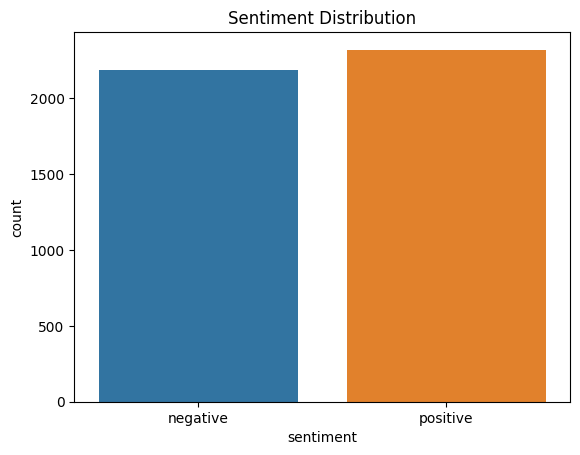

In [19]:
# 13. Sentiment Distribution Analysis
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

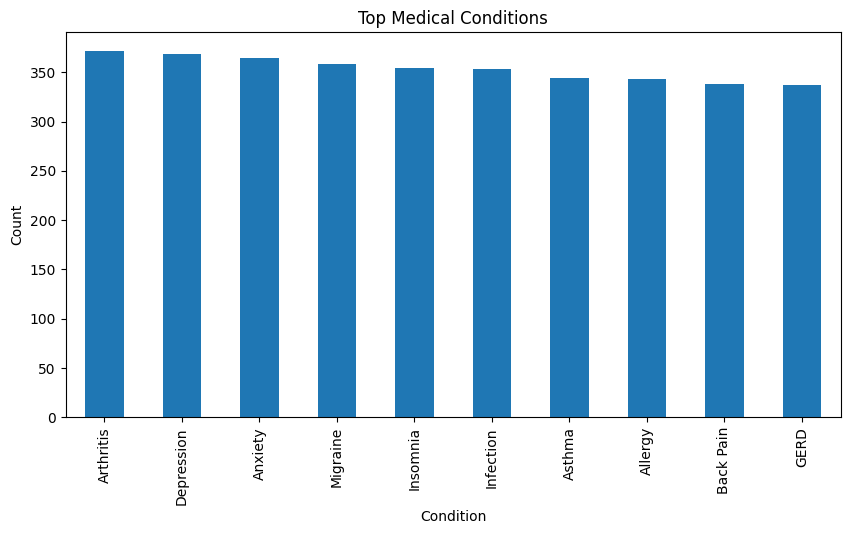

In [49]:
# 14. Medical Condition Frequency Analysis
plt.figure(figsize=(10,5))
df['condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Medical Conditions")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

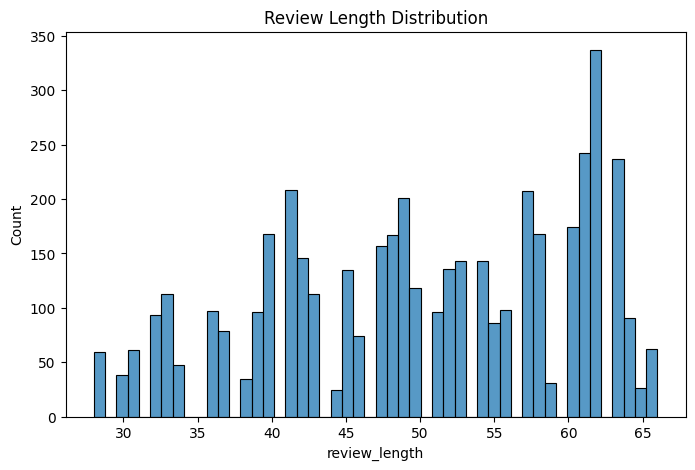

In [50]:
# 15. Review Length Analysis
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [51]:
# 16. Text Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub('<.*?>',' ',text)
    text = re.sub('[^a-zA-Z]',' ',text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [52]:
# 17. Creating Cleaned Review Text
df['clean_review'] = df['review'].apply(clean_text)

In [53]:
# 18. TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(max_features=5000)

In [54]:
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

In [55]:
# 19. Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
# 20. Training Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

LogisticRegression()

In [57]:
# 21. Training Naïve Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [58]:
# 22. Model Prediction
lr_predictions = lr_model.predict(X_test)
nb_predictions = nb_model.predict(X_test)

In [59]:
# 23. Model Accuracy Evaluation
lr_accuracy = accuracy_score(y_test, lr_predictions)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 1.0
Naive Bayes Accuracy: 1.0


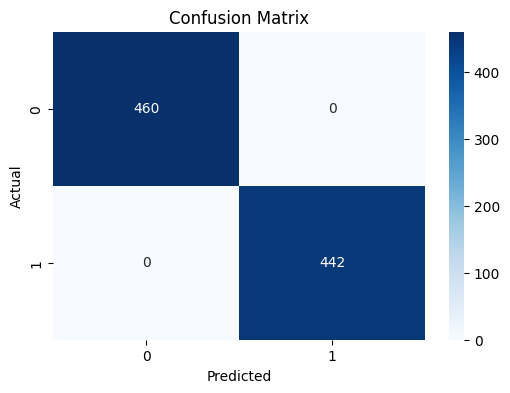

In [60]:
# 24. Confusion Matrix Visualization
cm = confusion_matrix(y_test, lr_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
# 25. Classification Report Analysis
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       460
    positive       1.00      1.00      1.00       442

    accuracy                           1.00       902
   macro avg       1.00      1.00      1.00       902
weighted avg       1.00      1.00      1.00       902



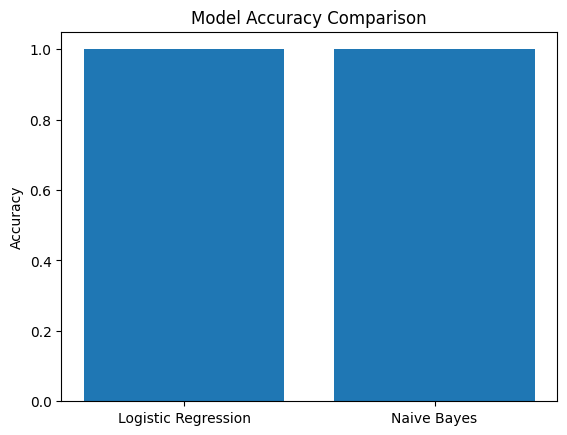

In [62]:
# 26. Model Accuracy Comparison Chart
models = ['Logistic Regression','Naive Bayes']
scores = [lr_accuracy, nb_accuracy]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [63]:
# 27. Saving the Cleaned Dataset
p=df.to_csv("clean_drug_reviews_5000.csv", index=False)